In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

3,965 books scraped from Goodreads, focused on the Indian reading market. It covers books across English and several Indian + Middle Eastern languages, spanning publications from the 1800s through 2024, with a heavy concentration in the 2000s–2010s.

In [16]:
df_raw = pd.read_csv('goodreads_enriched.csv')

In [17]:
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13,
                     'axes.labelsize': 11, 'xtick.labelsize': 9, 'ytick.labelsize': 9})

## Data Health

In [18]:
df_raw.head(4)

,title,author,genre,pages,rating,ratings_count,reviews_count,year,publisher,language,description,price
0,The Hunger Games,Suzanne Collins,"Young Adult, Dystopia, Fiction",374.0,4.35,10077406,268647,2008.0,NaN,NaN,Winning means fame and fortune. Losing means c...,NaN
1,Catching Jordan,Miranda Kenneally,"Young Adult, Romance, Contemporary",288.0,3.83,64721,3872,2011.0,NaN,NaN,ONE OF THE BOYSWhat girl doesn't want to be su...,NaN
2,The Boy Who Sneaks in My Bedroom Window,Kirsty Moseley,"Romance, Young Adult, Contemporary",256.0,3.84,78310,5995,2012.0,NaN,NaN,"Liam James, boy next door and total douchebag,...",NaN
3,The Vincent Boys,Abbi Glines,"Romance, Young Adult, New Adult",260.0,3.94,75284,3999,2011.0,NaN,NaN,"Ashton is getting tired of being good, of impr...",NaN


In [19]:
print("Shape:", df_raw.shape)
print("\nColumns:\n", df_raw.columns.tolist())
print("\nData Types:\n", df_raw.dtypes)

Shape: (3919, 12)

Columns:
 ['title', 'author', 'genre', 'pages', 'rating', 'ratings_count', 'reviews_count', 'year', 'publisher', 'language', 'description', 'price']

Data Types:
 title             object
author            object
genre             object
pages            float64
rating           float64
ratings_count      int64
reviews_count      int64
year             float64
publisher         object
language          object
description       object
price            float64
dtype: object


In [20]:
print(df_raw.isna().sum())

title               0
author              0
genre             325
pages             132
rating              0
ratings_count       0
reviews_count       0
year               56
publisher        2150
language         1274
description        75
price            3128
dtype: int64


In [21]:
df_raw.describe(include='all')

,title,author,genre,pages,rating,ratings_count,reviews_count,year,publisher,language,description,price
count,3919,3919,3594,3787.000000,3919.000000,3.919000e+03,3919.000000,3863.000000,1769,2645,3844,791.000000
unique,3890,2575,1634,NaN,NaN,NaN,NaN,NaN,622,22,3832,NaN
top,Warrior,Naguib Mahfouz,"Romance, Contemporary Romance, Contemporary",NaN,NaN,NaN,NaN,NaN,Hachette UK,en,Reading books is a kind of enjoyment. Reading ...,NaN
freq,3,26,77,NaN,NaN,NaN,NaN,NaN,120,2039,4,NaN
mean,NaN,NaN,NaN,304.313705,3.937267,1.003994e+05,4897.167900,1999.127880,NaN,NaN,NaN,580.988078
std,NaN,NaN,NaN,164.206306,0.345546,4.843883e+05,18003.383358,27.611958,NaN,NaN,NaN,476.897189
min,NaN,NaN,NaN,6.000000,2.000000,1.000000e+00,0.000000,1811.000000,NaN,NaN,NaN,0.000000
25%,NaN,NaN,NaN,200.000000,3.730000,3.795000e+02,53.000000,1996.000000,NaN,NaN,NaN,339.000000
50%,NaN,NaN,NaN,294.000000,3.940000,2.752000e+03,299.000000,2010.000000,NaN,NaN,NaN,454.210000
75%,NaN,NaN,NaN,378.000000,4.160000,2.059600e+04,1815.000000,2014.000000,NaN,NaN,NaN,708.670000


- Ratings count exhibits extremely high variability, with a large difference between median and maximum values, indicating a highly skewed distribution
- Review count also demonstrates strong right-skewness,showing only some books generates discussion among readers
- Ratings are concentrated within a relatively narrow range, indicating that most books receive moderately positive reader feedback

In [22]:
df = df_raw.copy()

In [23]:
# fixing datatypes
df['year'] = pd.to_numeric(df['year'], errors='coerce').astype('Int64')
df['pages'] = pd.to_numeric(df['pages'], errors='coerce').astype('Int64')

In [24]:
# strip whitespace from text cols
for col in ['title', 'author', 'genre', 'description']:
    df[col] = df[col].str.strip()

In [25]:
#duplicate check
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


## Univarite Analysis

### Categorical data

#### Authors

In [26]:
# top 10 authors with most books
top_authors = df['author'].value_counts().head(10)
total_authors = df['author'].nunique()
print(f"Total unique authors: {total_authors}")
print("Top 10 authors with most books:")
print(top_authors)

Total unique authors: 2575
Top 10 authors with most books:
author
Naguib Mahfouz         26
Ahmed Khaled Towfik    25
Agatha Christie        19
Hamilton Crane         17
S.L. Bhyrappa          17
Meg Cabot              16
عبدالرحمن منيف         15
Mostafa Mahmoud        14
Mahmoud Darwish        14
Tawfiq Al-Hakim        13
Name: count, dtype: int64


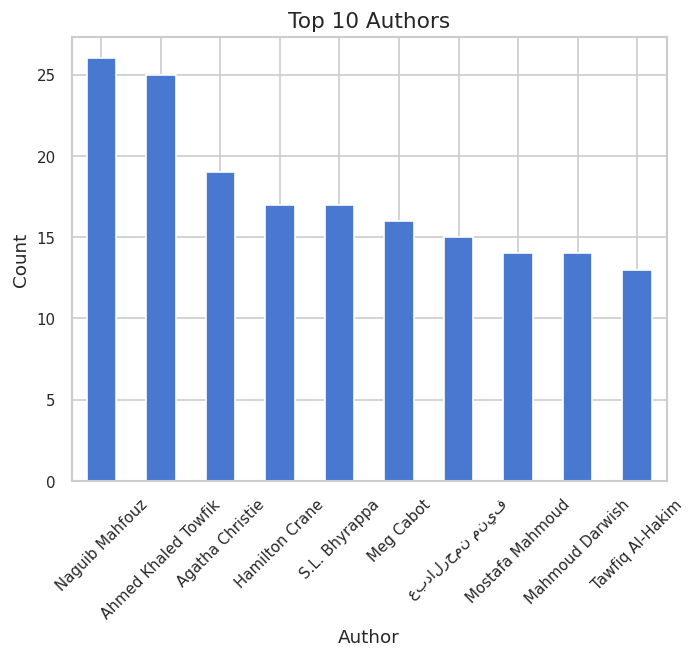

In [27]:
plt.figure()
top_authors.plot(kind='bar')
plt.title("Top 10 Authors")
plt.xlabel("Author")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

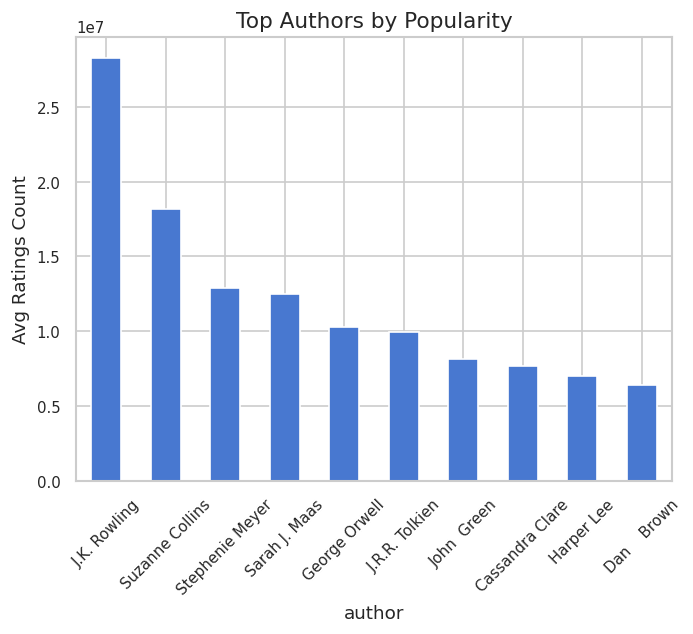

In [28]:
# author popularity
author_pop = df.groupby('author')['ratings_count'].sum().sort_values(ascending=False).head(10)

plt.figure()
author_pop.plot(kind='bar')
plt.title("Top Authors by Popularity")
plt.ylabel("Avg Ratings Count")
plt.xticks(rotation=45)
plt.show()

#### Genre

In [29]:
# top 10 genres
top_genres = df['genre'].value_counts().head(10)
print(f"Top 10 genres: {top_genres}")

Top 10 genres: genre
Romance, Contemporary Romance, Contemporary    77
Young Adult, Romance, Contemporary             65
Fantasy, Young Adult, Romance                  64
Novels, Fiction, Literature                    46
Romance, New Adult, Contemporary               41
Romance, Contemporary, Contemporary Romance    40
Romance, Young Adult, Contemporary             39
Fantasy, Young Adult, Fiction                  38
Young Adult, Paranormal, Fantasy               28
Young Adult, Fantasy, Paranormal               27
Name: count, dtype: int64


In [30]:
total_genres = df['genre'].nunique()
print(f"Total unique genres: {total_genres}")

Total unique genres: 1634


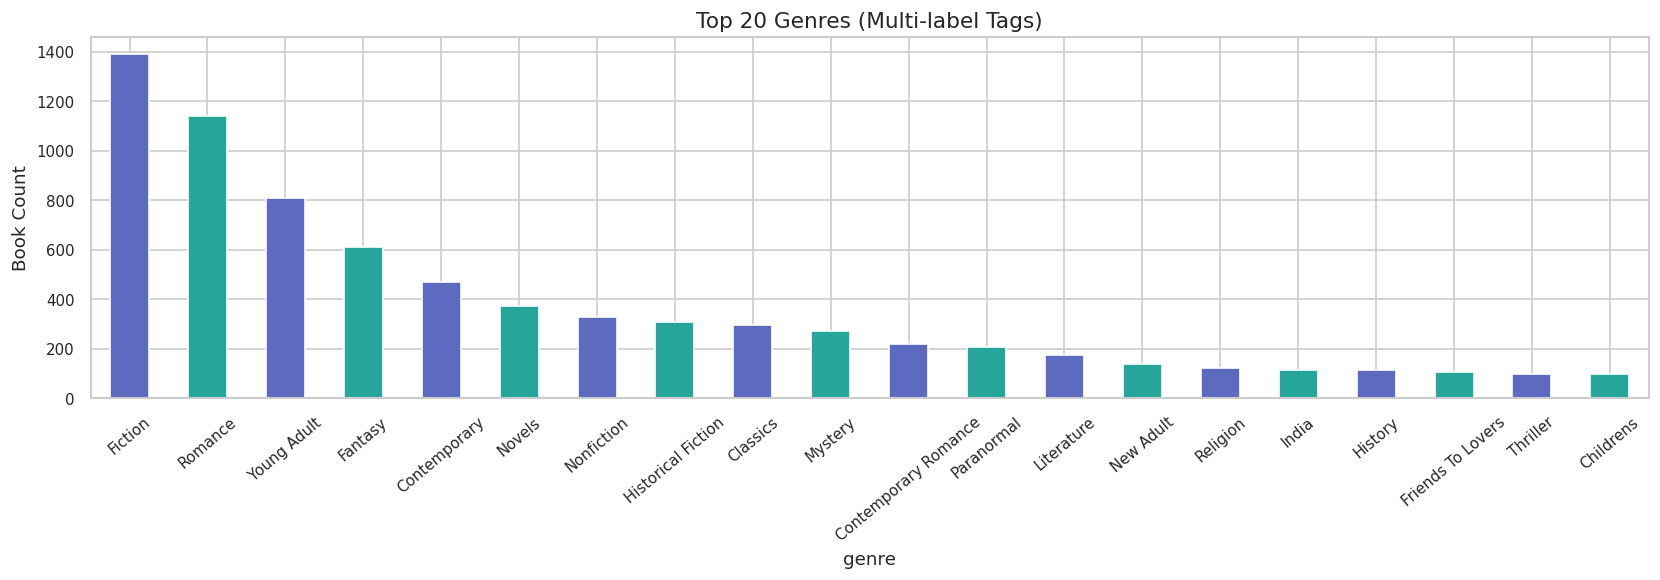

Unique genre tags  : 295
Avg tags per book  : 2.84


In [31]:
genres_exploded = df['genre'].dropna().str.split(',').explode().str.strip()
top12_genre_counts = genres_exploded.value_counts().head(12)

top20_genres = genres_exploded.value_counts().head(20)

fig, ax = plt.subplots(figsize=(14, 5))
colors = ['#5C6BC0' if i%2==0 else '#26A69A' for i in range(len(top20_genres))]
top20_genres.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.set_title('Top 20 Genres (Multi-label Tags)')
ax.set_ylabel('Book Count'); ax.tick_params(axis='x', rotation=40)
plt.tight_layout(); plt.show()

print(f"Unique genre tags  : {genres_exploded.nunique()}")
print(f"Avg tags per book  : {df['genre'].dropna().str.split(',').apply(len).mean():.2f}")

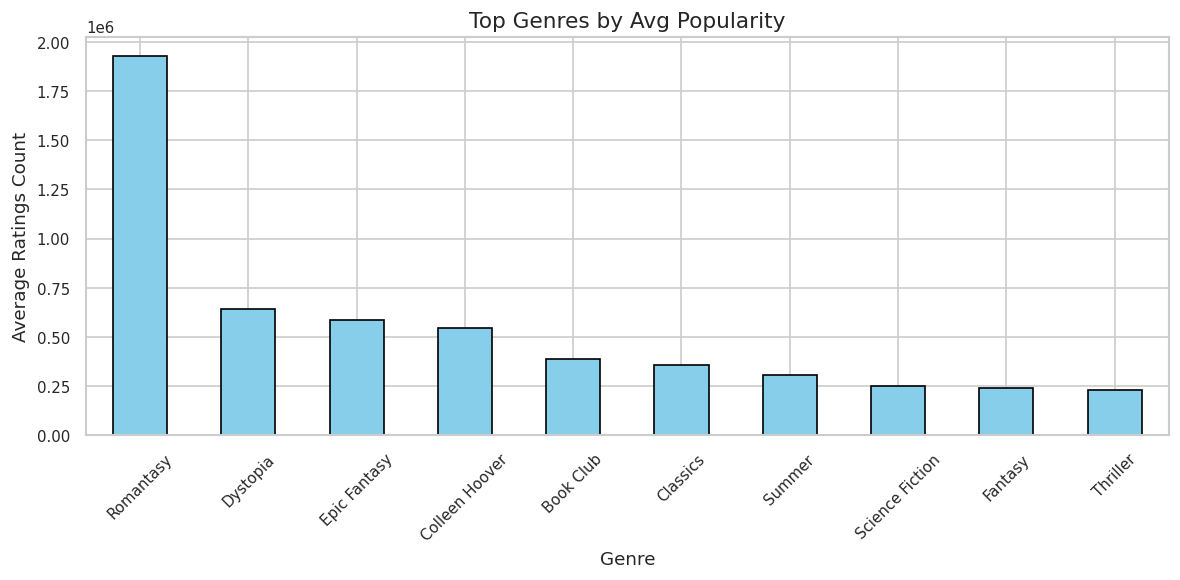

In [32]:
# genre vs popularity
genre_df = (
    df[['genre', 'ratings_count']]
    .dropna(subset=['genre'])
    .assign(genre_list=df['genre'].str.split(','))
    .explode('genre_list')
)

genre_df['genre_list'] = genre_df['genre_list'].str.strip()

genre_pop = (
    genre_df
    .groupby('genre_list')['ratings_count']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

genre_pop.plot(
    kind='bar',
    color='skyblue',
    edgecolor='black'
)

plt.title("Top Genres by Avg Popularity")
plt.ylabel("Average Ratings Count")
plt.xlabel("Genre")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

- the genre column contains multiple values per entry, leading to a large number of unique combinations and making direct analysis difficult. So this will be handled  in the preprocessing stage using multi-label encoding.

- genre column contains noisy data — some rows include author names mixed with genres

In [33]:
import re

# Cleaning function
def clean_text(text):
    text = str(text).lower().strip()
    text = re.sub(r'[^a-z0-9 ]', '', text)
    return text

# Clean author names
authors_clean = set(
    df['author']
    .dropna()
    .apply(clean_text)
)

# Clean exploded genres
genre_df['genre_clean'] = genre_df['genre_list'].apply(clean_text)

# Find matching author names inside genres
author_in_genre = genre_df[
    genre_df['genre_clean'].isin(authors_clean)
]

# Total matches
print("Total rows with author names in genres:")
print(len(author_in_genre))

# Unique invalid genre values
print("\nUnique author names found inside genres:")
print(author_in_genre['genre_list'].drop_duplicates().tolist())

Total rows with author names in genres:
22

Unique author names found inside genres:
['Colleen Hoover', 'Agatha Christie', 'Jane Austen']


#### Publishers

In [34]:
total_publisher_count = df['publisher'].nunique()
print(f"Total unique publishers: {total_publisher_count}")

Total unique publishers: 622


In [35]:
import re

publisher_patterns = {
    'HarperCollins': [r'harper'],
    'Penguin': [r'penguin'],
    'Random House': [r'random house'],
    'CreateSpace': [r'createspace'],
    'Simon & Schuster': [r'simon']
}

def normalize_publisher(pub):

    if pd.isna(pub):
        return pub

    pub_lower = pub.lower()

    for standard_name, patterns in publisher_patterns.items():

        for pattern in patterns:

            if re.search(pattern, pub_lower):
                return standard_name

    return pub.title()

In [36]:
df['publisher_clean'] = df['publisher'].apply(normalize_publisher)

In [37]:
publisher_count_clean = df['publisher_clean'].nunique()
print(f"Total unique cleaned publishers: {publisher_count_clean}")

Total unique cleaned publishers: 588


In [38]:
df['publisher_clean'].value_counts().head(10)

,count
publisher_clean,
Penguin,131
HarperCollins,129
Hachette Uk,120
Simon & Schuster,114
CreateSpace,102
Random House,64
Pan Macmillan,24
Harlequin,22
National Geographic Books,21


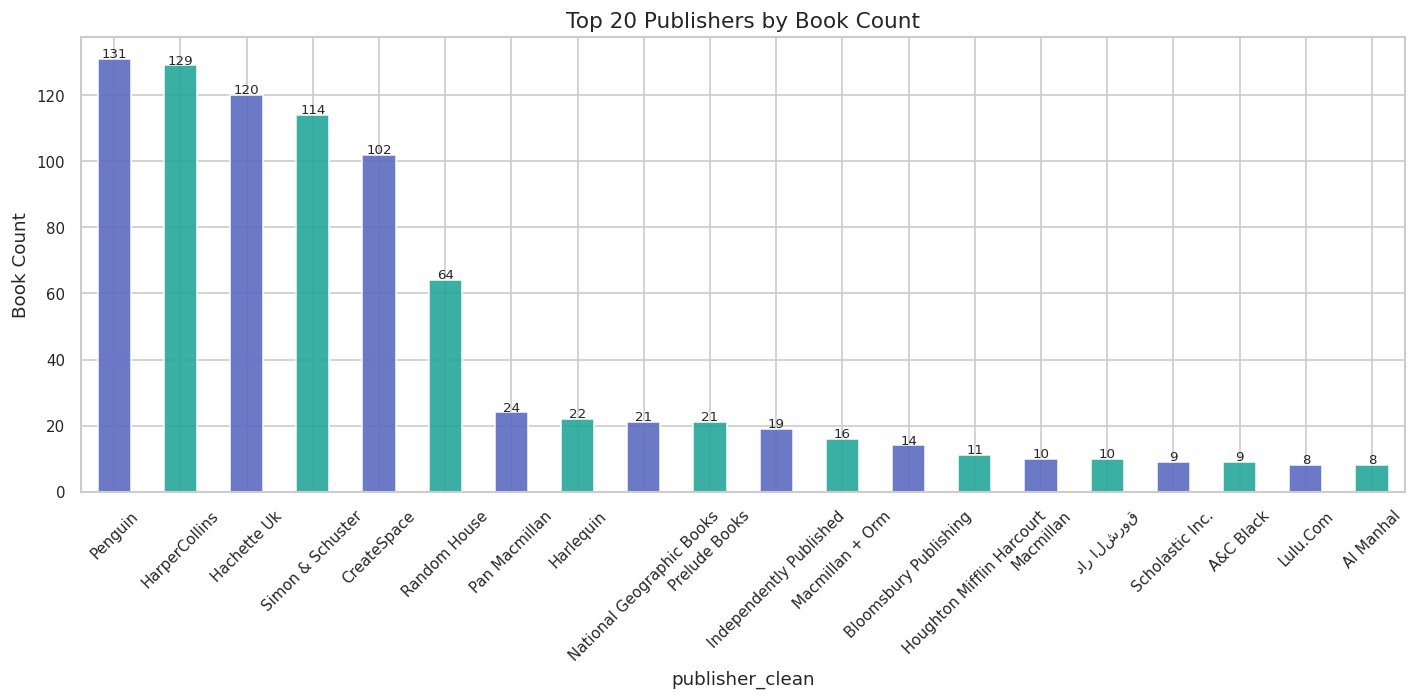

In [39]:
top20_pub = df['publisher_clean'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#5C6BC0' if i % 2 == 0 else '#26A69A' for i in range(len(top20_pub))]
top20_pub.plot(kind='bar', ax=ax, color=colors, edgecolor='white', alpha=0.9)
ax.set_ylabel('Book Count')
ax.set_title('Top 20 Publishers by Book Count')
ax.tick_params(axis='x', rotation=45)
for i, v in enumerate(top20_pub):
    ax.text(i, v+0.5, str(v), ha='center', fontsize=8)
plt.tight_layout(); plt.show()

#### Language

In [40]:
total_lang = df['language'].value_counts()
print("Number of Languages :\n", len(total_lang))
print("\nTop languages:\n", total_lang.head(10))

Number of Languages :
 22

Top languages:
 language
en    2039
ar     451
hi      28
tr      24
ta      19
de      14
bn      14
es       9
kn       8
id       7
Name: count, dtype: int64


    'en':'English', 'ar':'Arabic',  'hi':'Hindi',    'tr':'Turkish',
    'ta':'Tamil',   'de':'German',  'bn':'Bengali',  'es':'Spanish',
    'kn':'Kannada', 'id':'Indonesian','it':'Italian','fr':'French',
    'ml':'Malayalam','te':'Telugu', 'da':'Danish',   'ur':'Urdu',
    'ja':'Japanese','zh':'Chinese', 'ru':'Russian',  'pt':'Portuguese',
    'nl':'Dutch',   'ko':'Korean',  'pl':'Polish',   'sv':'Swedish',
    'no':'Norwegian','fi':'Finnish'

### Numerical data

#### Pages

In [41]:
max_pg = df['pages'].max()
min_pg = df['pages'].min()
print(f"Max pages: {max_pg}")
print(f"Min pages: {min_pg}")

Max pages: 1867
Min pages: 6


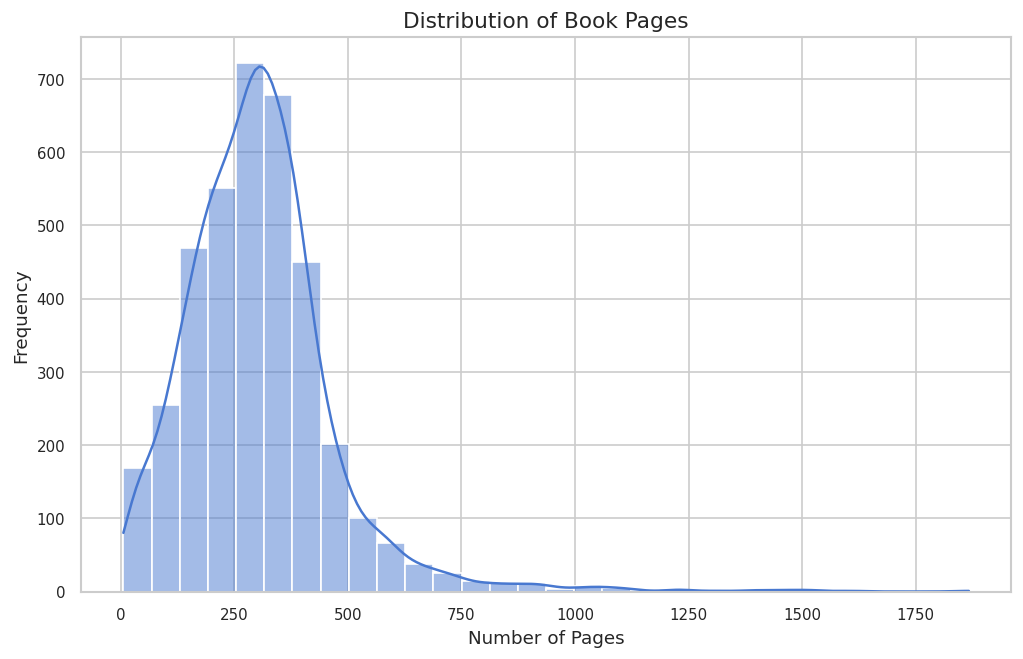

In [42]:
plt.figure(figsize=(10, 6))
sns.histplot(df['pages'], bins=30, kde=True)
plt.title('Distribution of Book Pages')
plt.xlabel('Number of Pages')
plt.ylabel('Frequency')
plt.show()

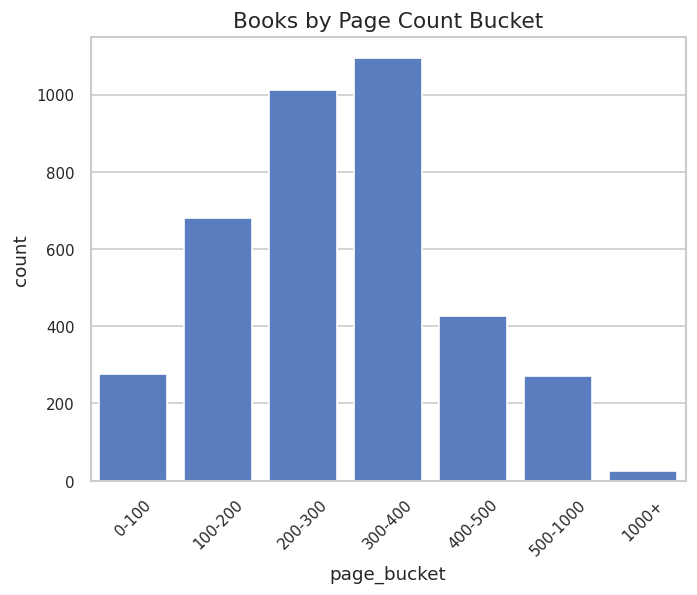

In [43]:
df['page_bucket'] = pd.cut(
    df['pages'],
    bins=[0, 100, 200, 300, 400, 500, 1000, float('inf')],
    labels=['0-100', '100-200', '200-300', '300-400', '400-500', '500-1000', '1000+']
)
sns.countplot(data=df, x='page_bucket')
plt.xticks(rotation=45)
plt.title('Books by Page Count Bucket')
plt.show()

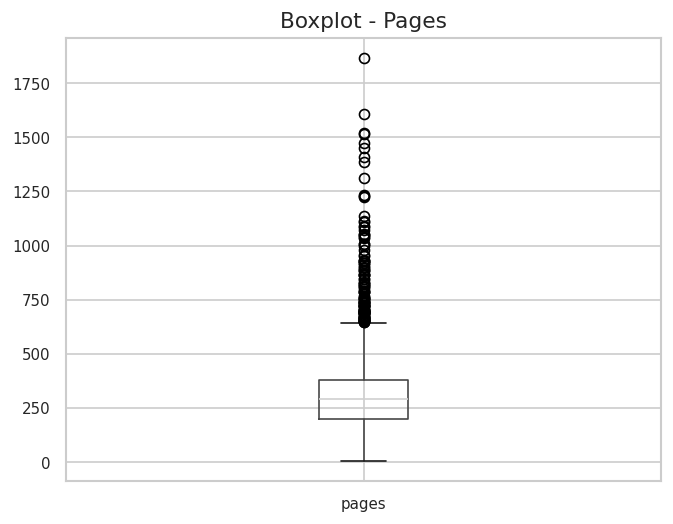

In [44]:
#outliers in pages
plt.figure()
df.boxplot(column='pages')
plt.title("Boxplot - Pages")
plt.show()

In [45]:
pg_below_10 = df[df['pages'] < 10][['title', 'pages']]
print("Books with page count below 10:\n", pg_below_10)
print(f"Number of books with page count below 10: {len(pg_below_10)}")

Books with page count below 10:
                                        title  pages
53                          Savor the Moment      9
1139  A Lady's Guide to Etiquette and Murder      9
2287                            البيت المسلم      8
2301                          السيرة النبوية      6
2304                       دورة الوعي اللغوي      8
3752                                    कफ़न      7
Number of books with page count below 10: 6


For some of the books with pages below 10  the entries are wrong ,this was found out manually . These value will be hard-coded with verified values during the Preprocessing

In [47]:
print("\nTop 10 longest books:")
display(df.nlargest(10,'pages')[['title','author','pages','genre']])

# Year flags
print(f"\nFuture years (>2026): {(df['year'] > 2026).sum()}")
print(f"Very old  (<1500)   : {(df['year'] < 1500).sum()}")
df['year_flag'] = ~df['year'].between(1500, 2026)

# Log-transform ratings count for analysis
df['log_ratings'] = np.log1p(df['ratings_count'])
print(f"\nratings_count range: {df['ratings_count'].min():,} → {df['ratings_count'].max():,}")


Top 10 longest books:


,title,author,pages,genre
1749,موسوعة أسماء الله الحسنى,محمد راتب النابلسي,1867,"Religion, Islam, Faith"
1628,أنت لي,منى المرشود,1607,"Novels, Romance, Fiction"
3020,The Mortal Instruments Boxed Set: City of Bone...,Cassandra Clare,1520,"Fantasy, Young Adult, Romance"
2313,النظريات العلمية الحديثة - مسيرتها الفكرية وأس...,حسن بن محمد حسن الأسمري,1515,Science
3584,A Suitable Boy,Vikram Seth,1474,"Fiction, India, Historical Fiction"
3744,"பொன்னியின் செல்வன், முழுத்தொகுப்பு",Kalki Krishnamurthy,1452,"Fiction, Historical Fiction, Classics"
3741,"வீரயுக நாயகன் வேள்பாரி, முழுத்தொகுப்பு",Su. Venkatesan,1408,"Fiction, Indian Literature, Historical Fiction"
1706,تاريخ أوروبا والعالم في العصر الحديث، الجزء الأول,عبد العظيم رمضان,1386,History
1738,"The Cairo Trilogy: Palace Walk, Palace of Desi...",Naguib Mahfouz,1313,"Fiction, Historical Fiction, Egypt"
1101,Gai-Jin,James Clavell,1236,"Historical Fiction, Fiction, Japan"



Future years (>2026): 0
Very old  (<1500)   : 0

ratings_count range: 1 → 11,590,973


#### Year

In [48]:
years_max = df['year'].max()
years_min = df['year'].min()
print(f"Max year: {years_max}")
print(f"Min year: {years_min}")

Max year: 2025
Min year: 1811


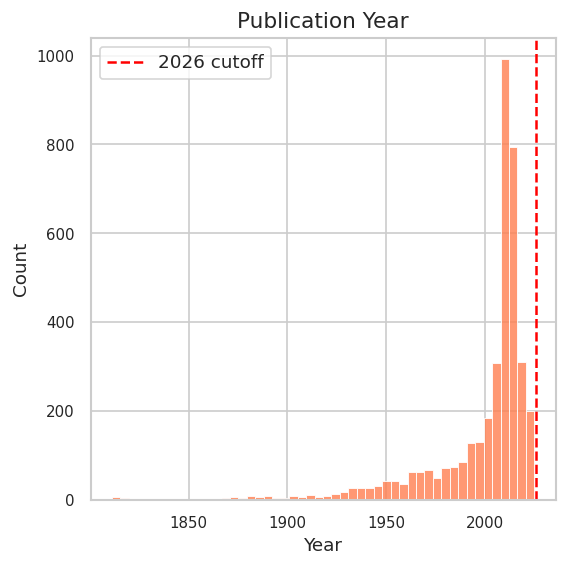

In [49]:
yr = df['year'].dropna().astype(int)
yr = yr[yr.between(1800, 2026)]
plt.figure(figsize=(5, 5))
sns.histplot(yr,bins=50,color='coral',edgecolor='white',alpha=0.8)

plt.axvline(2026,color='red',linestyle='--',linewidth=1.5,label='2026 cutoff')

plt.legend()
plt.title('Publication Year')
plt.xlabel('Year')

plt.show()

#### Rating - score given by readers.

In [50]:
rat_max = df['rating'].max()
rat_min = df['rating'].min()
print(f"Max rating: {rat_max}")
print(f"Min rating: {rat_min}")

Max rating: 5.0
Min rating: 2.0


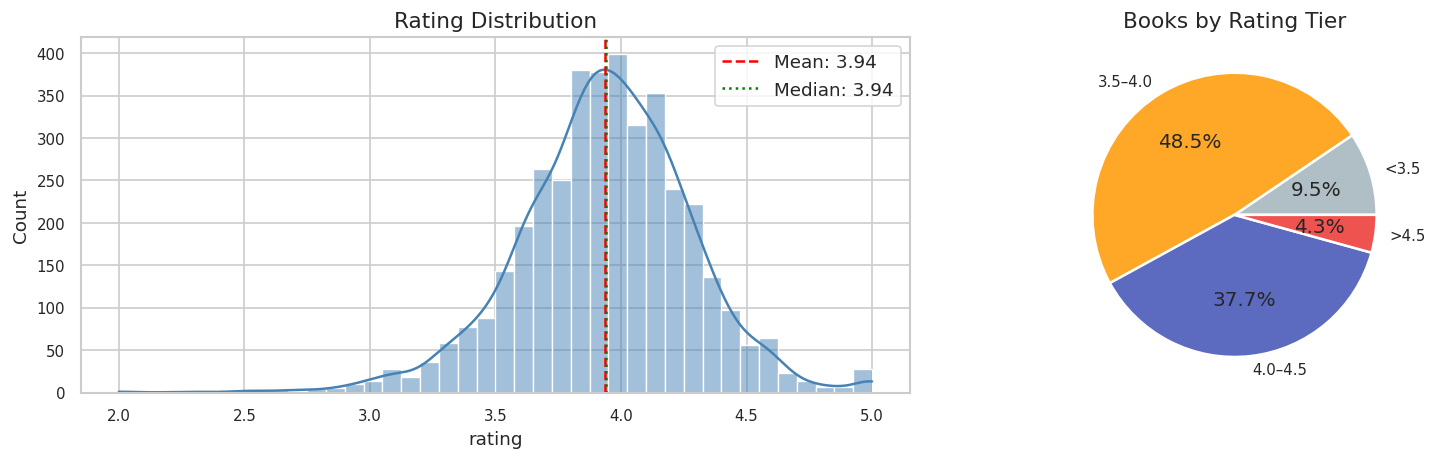

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df['rating'], bins=40, kde=True, ax=axes[0], color='steelblue')
axes[0].axvline(df['rating'].mean(),   color='red',   linestyle='--', lw=1.5, label=f'Mean: {df["rating"].mean():.2f}')
axes[0].axvline(df['rating'].median(), color='green', linestyle=':',  lw=1.5, label=f'Median: {df["rating"].median():.2f}')
axes[0].legend(); axes[0].set_title('Rating Distribution')

df['rating_tier'] = pd.cut(df['rating'], bins=[0,3.5,4.0,4.5,5.0],
                            labels=['<3.5','3.5–4.0','4.0–4.5','>4.5'])
tier_counts = df['rating_tier'].value_counts().sort_index()
axes[1].pie(tier_counts, labels=tier_counts.index, autopct='%1.1f%%',
            colors=['#B0BEC5','#FFA726','#5C6BC0','#EF5350'],
            wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1].set_title('Books by Rating Tier')

plt.tight_layout(); plt.show()

#### Rating count - Total number of people who rated the book

In [52]:
rat_count_max = df['ratings_count'].max()
rat_count_min = df['ratings_count'].min()
print(f"Max rating count: {rat_count_max}")
print(f"Min rating count: {rat_count_min}")

Max rating count: 11590973
Min rating count: 1


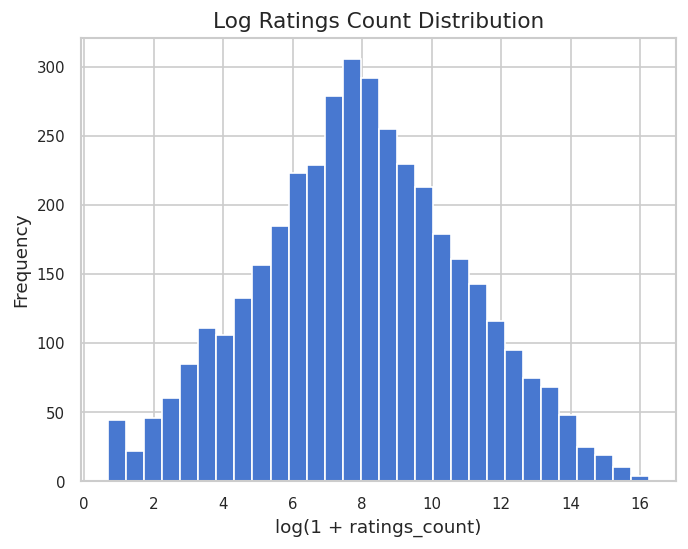

In [53]:
plt.figure()
np.log1p(df['ratings_count']).hist(bins=30)
plt.title("Log Ratings Count Distribution")
plt.xlabel("log(1 + ratings_count)")
plt.ylabel("Frequency")
plt.show()

#### Review count - Number of written reviews

In [54]:
review_count_max = df['reviews_count'].max()
review_count_min = df['reviews_count'].min()
print(f"Max review count: {review_count_max}")
print(f"Min review count: {review_count_min}")

Max review count: 326656
Min review count: 0


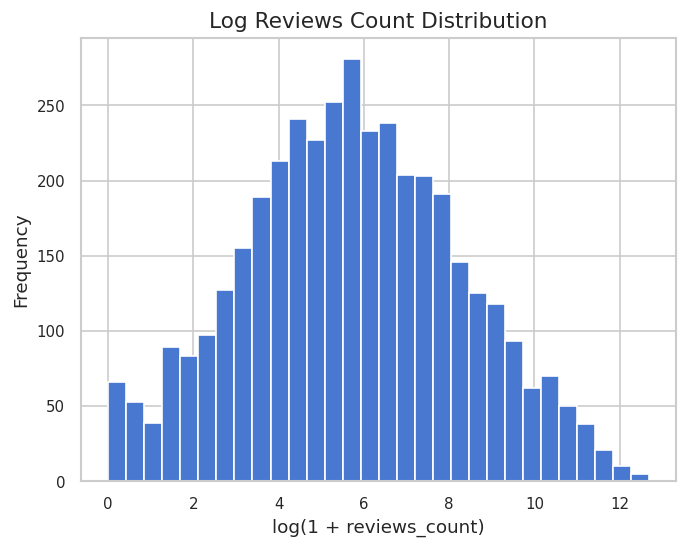

In [55]:
plt.figure()
np.log1p(df['reviews_count']).hist(bins=30)
plt.title("Log Reviews Count Distribution")
plt.xlabel("log(1 + reviews_count)")
plt.ylabel("Frequency")
plt.show()

#### Price

In [56]:
max_price = df['price'].max()
min_price = df['price'].min()
print(f"Max price: {max_price}")
print(f"Min price: {min_price}")

Max price: 5806.78
Min price: 0.0


In [62]:
print(f"Price = 0  : {(df['price'] == 0).sum()} rows")
print(f"Price > 3000: {(df['price'] > 3000).sum()} rows")

# Inspect extremes
print("\nMost expensive books:")
display(df.nlargest(10, 'price')[['title','author','price','publisher_clean']])

# Treat price = 0 as missing
#df.loc[df['price'] == 0, 'price'] = np.nan

Price = 0  : 20 rows
Price > 3000: 5 rows

Most expensive books:


,title,author,price,publisher_clean
3685,ഗുരുസാഗരം | Gurusagaram,ഒ.വി.വിജയൻ | O.V.Vijayan,5806.78,Taylor & Francis
2209,‫هكذا علمتني الحياة‬,مصطفى السباعي,3914.75,Ktab Inc.
2372,Life As We Knew It,Susan Beth Pfeffer,3749.78,HarperCollins
966,Jet,Jay Crownover,3678.67,HarperCollins
3678,രണ്ടിടങ്ങഴി | Randidangazhi,തകഴി |Thakazhi Sivasankara Pillai,3138.80,Routledge
1998,حياتي,أحمد أمين,2572.23,Ktab Inc.
1254,Murder in an Italian Village,Michael Falco,2567.49,Kensington Cozies
1289,Murder at the Majestic Hotel,Clara McKenna,2472.68,Kensington Books
1594,في صالون العقاد كانت لنا أيام,أنيس منصور,2465.09,Nahdet Misr Publishing Group
1578,عبقرية محمد,عباس محمود العقاد,2236.60,Ktab Inc.


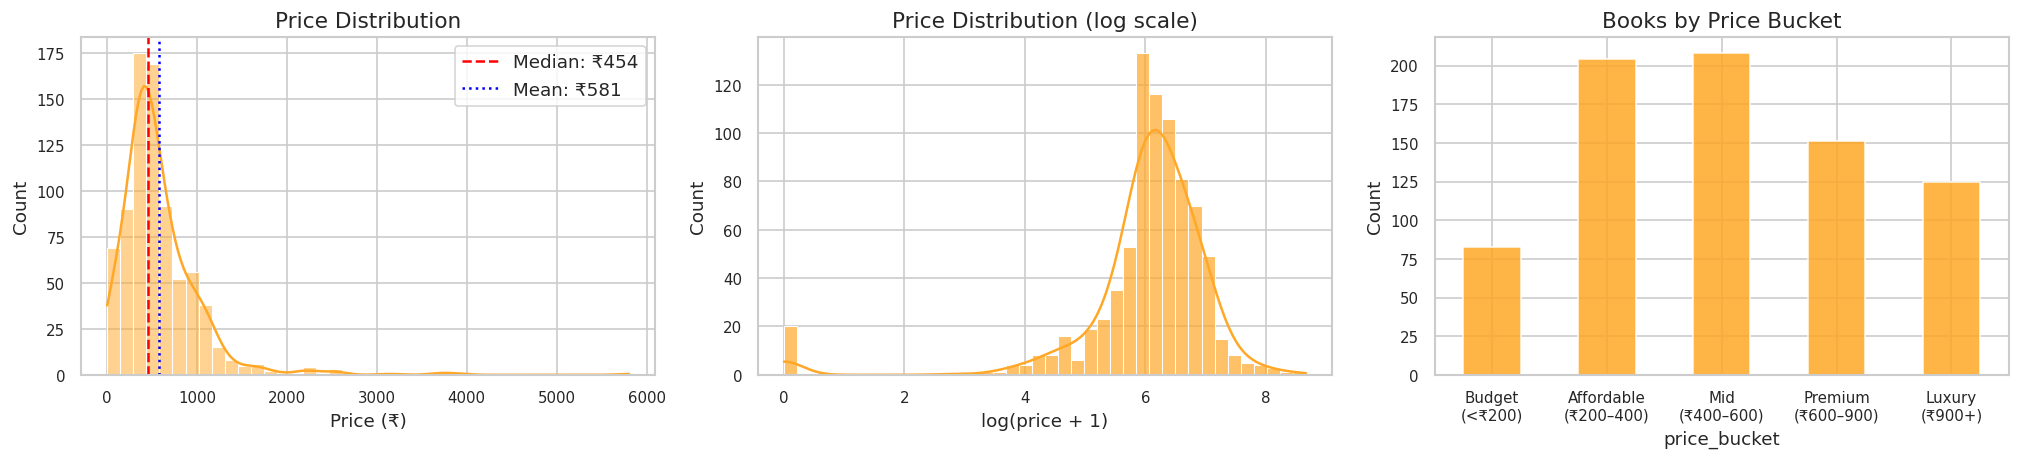

count     791.00
mean      580.99
std       476.90
min         0.00
25%       339.00
50%       454.21
75%       708.67
max      5806.78
Name: price, dtype: float64

Skewness : 3.808
Coverage : 791 / 3919 books (20.2%)


In [63]:
price_clean = df['price'].dropna()

fig, axes = plt.subplots(1, 3, figsize=(17, 4))

# Histogram
sns.histplot(price_clean, bins=40, kde=True, ax=axes[0], color='#FFA726')
axes[0].axvline(price_clean.median(), color='red', linestyle='--', lw=1.5,
                label=f'Median: ₹{price_clean.median():.0f}')
axes[0].axvline(price_clean.mean(), color='blue', linestyle=':', lw=1.5,
                label=f'Mean: ₹{price_clean.mean():.0f}')
axes[0].legend(); axes[0].set_xlabel('Price (₹)')
axes[0].set_title('Price Distribution')

# Log scale
sns.histplot(np.log1p(price_clean), bins=40, kde=True, ax=axes[1], color='#FFA726', alpha=0.7)
axes[1].set_xlabel('log(price + 1)'); axes[1].set_title('Price Distribution (log scale)')

# Price buckets
df['price_bucket'] = pd.cut(df['price'],
    bins=[0, 200, 400, 600, 900, 10000],
    labels=['Budget\n(<₹200)', 'Affordable\n(₹200–400)',
            'Mid\n(₹400–600)', 'Premium\n(₹600–900)', 'Luxury\n(₹900+)'])
df['price_bucket'].value_counts().sort_index().plot(
    kind='bar', ax=axes[2], color='#FFA726', edgecolor='white', alpha=0.85)
axes[2].set_title('Books by Price Bucket')
axes[2].set_ylabel('Count'); axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout(); plt.show()

print(price_clean.describe().round(2))
print(f"\nSkewness : {price_clean.skew():.3f}")
print(f"Coverage : {len(price_clean)} / {len(df)} books ({len(price_clean)/len(df)*100:.1f}%)")

/tmp/ipykernel_1298/1381177538.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_rating = df.groupby('price_bucket')['rating'].mean()


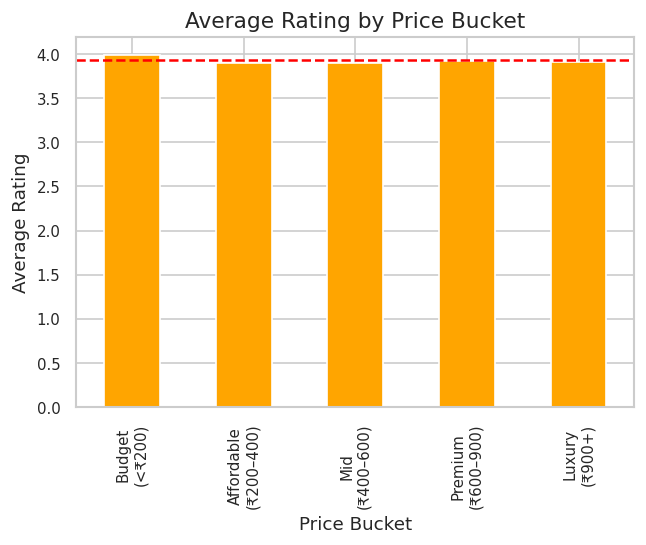

In [64]:
bucket_rating = df.groupby('price_bucket')['rating'].mean()

plt.figure(figsize=(6,4))

bucket_rating.plot(
    kind='bar',
    color='orange'
)

plt.xlabel("Price Bucket")
plt.ylabel("Average Rating")
plt.title("Average Rating by Price Bucket")

plt.axhline(df['rating'].mean(), color='red', linestyle='--')

plt.show()

## Bivaraite Analysis

#### Price vs Rating

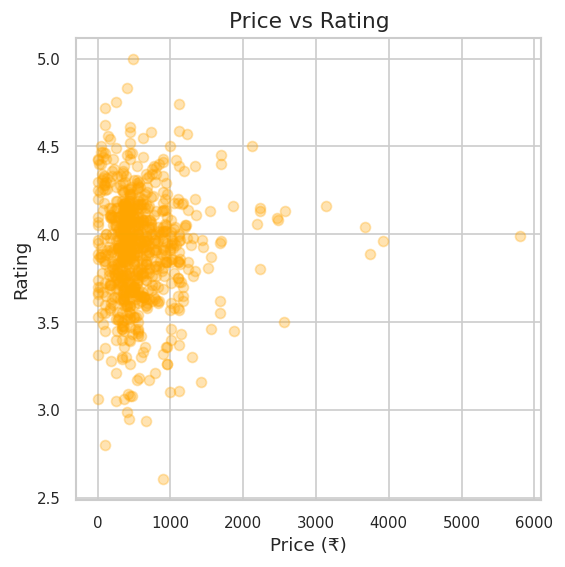

In [65]:
plt.figure(figsize=(5,5))

plt.scatter(
    df['price'],
    df['rating'],
    alpha=0.3,
    color='orange'
)

plt.xlabel("Price (₹)")
plt.ylabel("Rating")
plt.title("Price vs Rating")

plt.show()

Ratings appear relatively independent of book pricing

#### Rating vs popularity

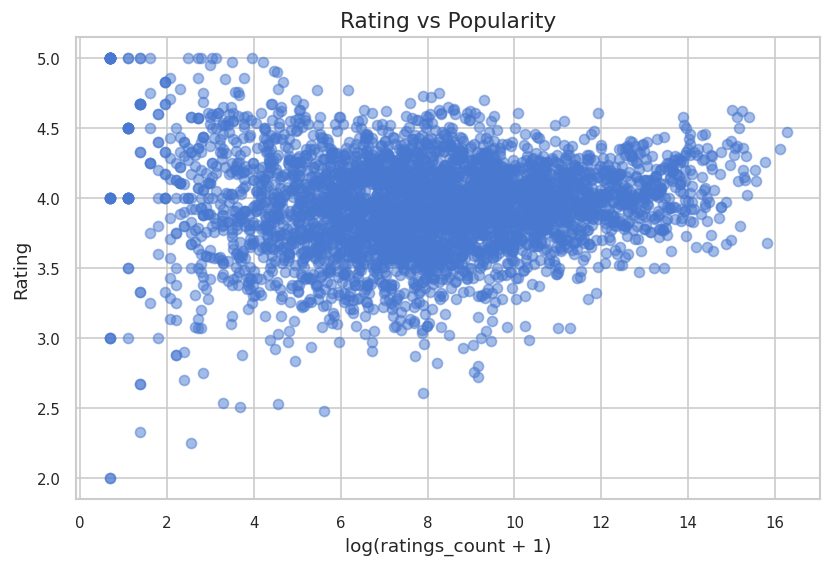

In [66]:
plt.figure(figsize=(8, 5))

plt.scatter(df['log_ratings'],df['rating'],alpha=0.5)

# Labels and title
plt.xlabel('log(ratings_count + 1)')
plt.ylabel('Rating')
plt.title('Rating vs Popularity')

plt.show()

#### Genre vs Rating

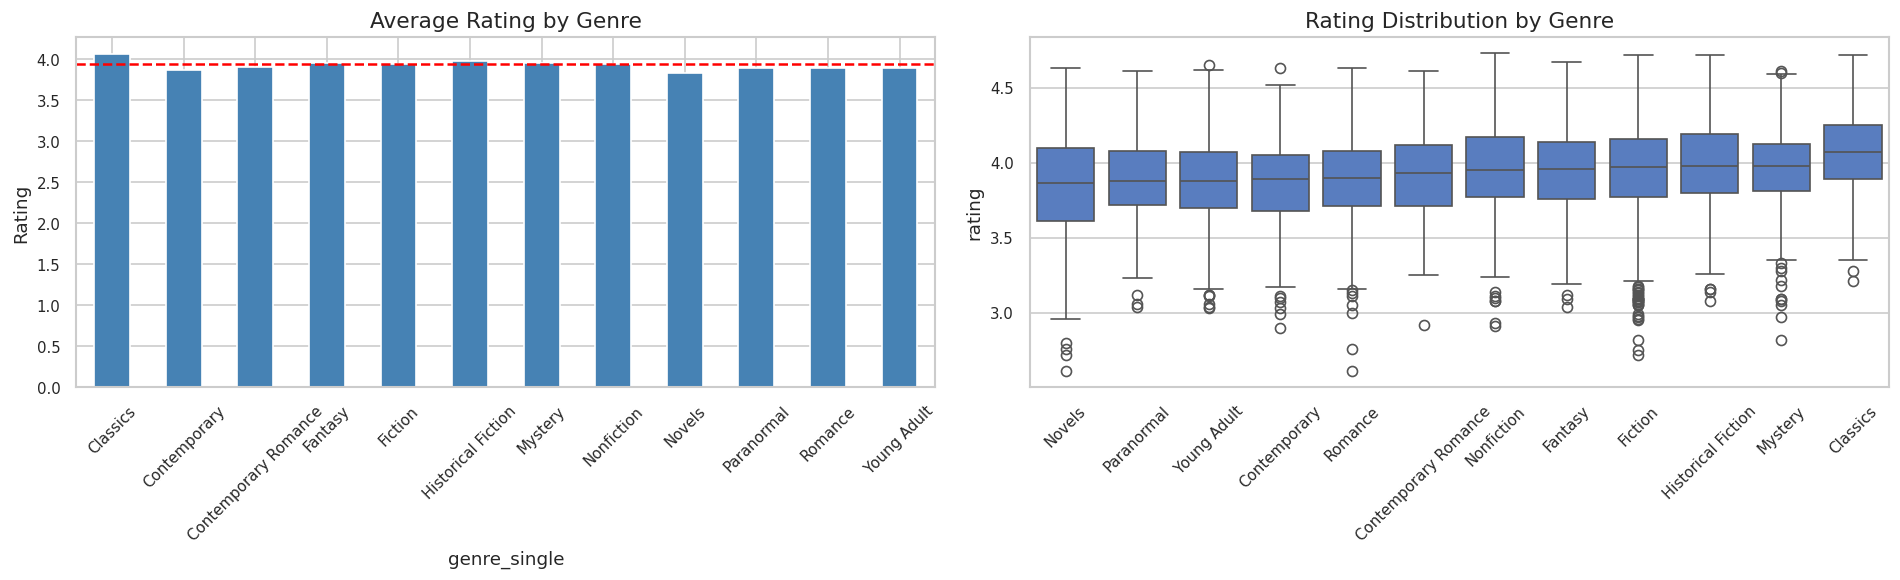

In [67]:
top12 = genres_exploded.value_counts().head(12).index.tolist()

df_exp = df.copy()

df_exp['genre_single'] = df_exp['genre'].str.split(',')
df_exp = df_exp.explode('genre_single')

df_exp['genre_single'] = df_exp['genre_single'].str.strip()

df_top = df_exp[df_exp['genre_single'].isin(top12)]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

genre_avg = df_top.groupby('genre_single')['rating'].mean()

genre_avg.plot(kind='bar',ax=axes[0],color='steelblue')
axes[0].axhline(df['rating'].mean(),color='red',linestyle='--')
axes[0].set_title("Average Rating by Genre")
axes[0].set_ylabel("Rating")
axes[0].tick_params(axis='x', rotation=45)

order = df_top.groupby('genre_single')['rating'].median().sort_values().index

sns.boxplot(data=df_top,x='genre_single',y='rating',order=order,ax=axes[1])

axes[1].set_title("Rating Distribution by Genre")
axes[1].set_xlabel("")
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


- Genre alone doesn't explain rating differences

#### Pages vs genre and rating

/tmp/ipykernel_1298/3407221025.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(box_data, labels=top8)


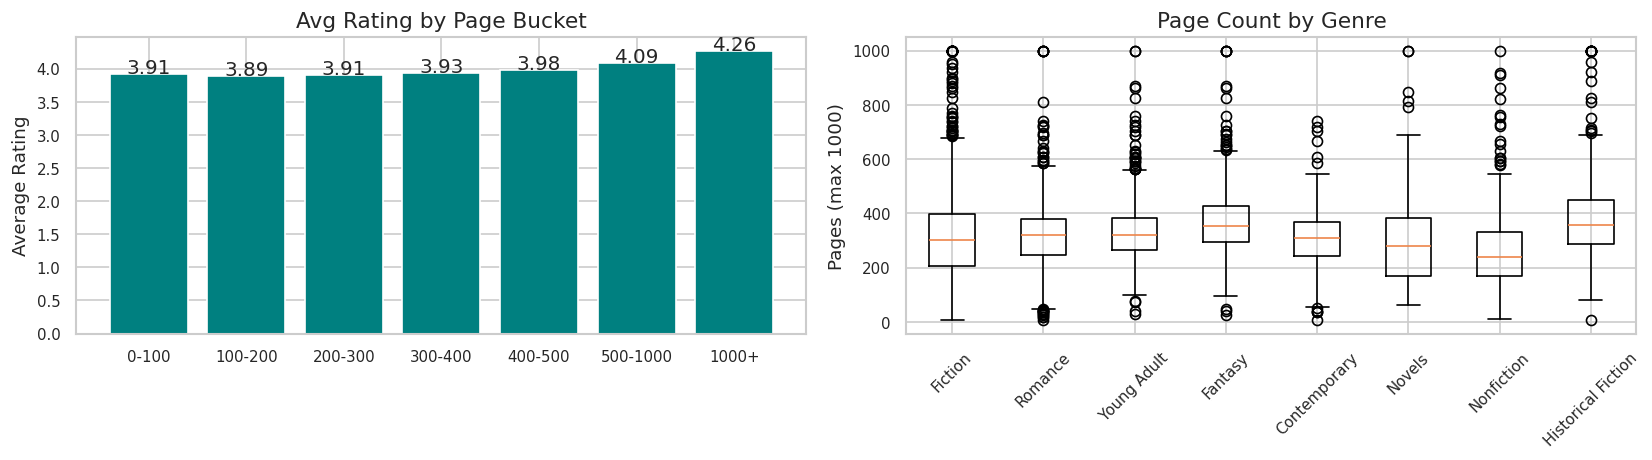

In [68]:
page_rating = (
    df.dropna(subset=['page_bucket', 'rating'])
      .groupby('page_bucket', observed=True)
      .agg(avg_rating=('rating', 'mean'),
           count=('rating', 'count'))
      .reset_index()
)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(
    page_rating['page_bucket'].astype(str),
    page_rating['avg_rating'],
    color='teal'
)

axes[0].set_title("Avg Rating by Page Bucket")
axes[0].set_ylabel("Average Rating")

# show values on top
for i, v in enumerate(page_rating['avg_rating']):
    axes[0].text(i, v + 0.01, f"{v:.2f}", ha='center')
top8 = genres_exploded.value_counts().head(8).index.tolist()

box_data = []

for g in top8:
    values = df_exp[df_exp['genre_single'] == g]['pages']
    values = values.dropna().clip(upper=1000)
    box_data.append(values)
axes[1].boxplot(box_data, labels=top8)

axes[1].set_title("Page Count by Genre")
axes[1].set_ylabel("Pages (max 1000)")
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

- There is a small upward trend for rating as books get longer
- Different genres exhibit different page count distributions

#### Popularity vs publication year

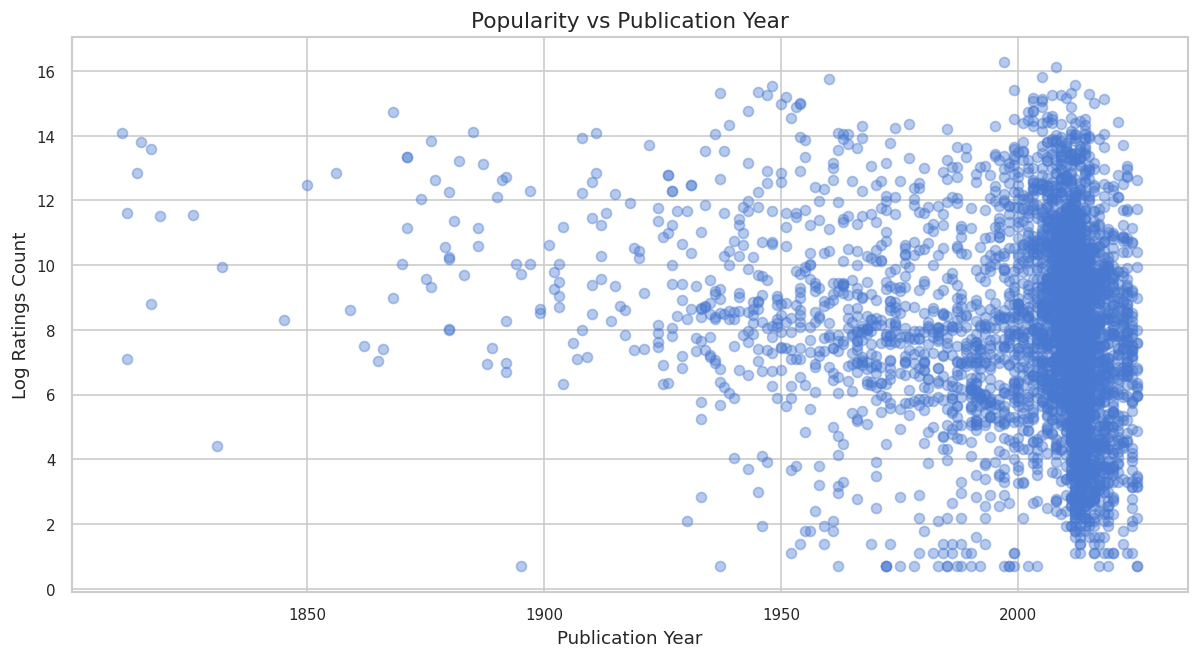

In [69]:
plt.figure(figsize=(12,6))

plt.scatter(
    df['year'],
    df['log_ratings'],
    alpha=0.4
)

plt.title('Popularity vs Publication Year')
plt.xlabel('Publication Year')
plt.ylabel('Log Ratings Count')

plt.show()

The relationship between publication year and popularity appears weak overall, as books from both older and newer periods exhibit a wide range of popularity levels

#### Rating vs rating count

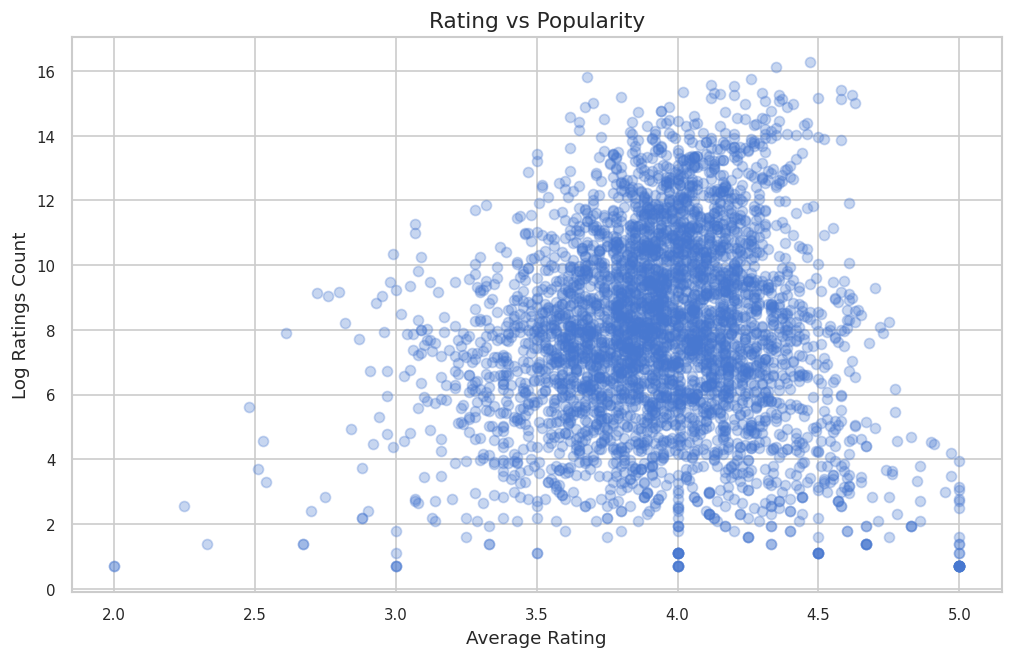

In [70]:
plt.figure(figsize=(10,6))

plt.scatter(
    df['rating'],
    df['log_ratings'],
    alpha=0.3
)

plt.xlabel('Average Rating')
plt.ylabel('Log Ratings Count')
plt.title('Rating vs Popularity')

plt.show()

- Average rating alone does not strongly determine book popularity, as books with similar ratings exhibit widely different popularity levels
- Some books with high average ratings have relatively low ratings counts, while some widely popular books maintain only moderate ratings

#### Reviews Count vs Ratings Count

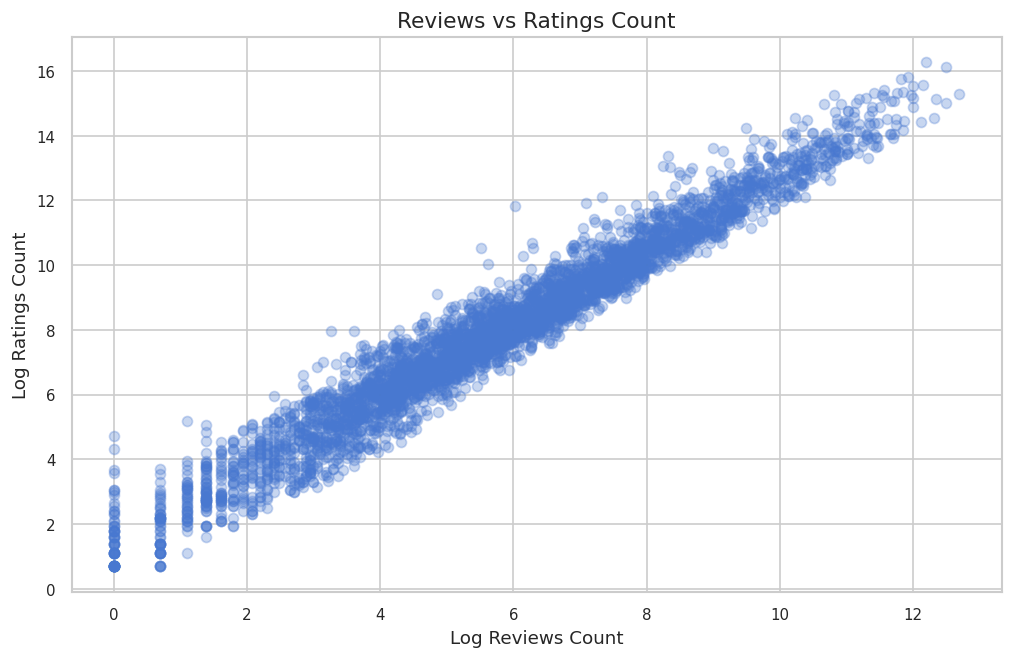

In [71]:
df['log_reviews_count'] = np.log1p(df['reviews_count'])
plt.figure(figsize=(10,6))

plt.scatter(
    df['log_reviews_count'],
    df['log_ratings'],
    alpha=0.3
)

plt.xlabel('Log Reviews Count')
plt.ylabel('Log Ratings Count')
plt.title('Reviews vs Ratings Count')

plt.show()

Books with higher ratings counts generally also receive higher review counts, indicating a strong positive relationship between readership size and reader engagement

### Correlation Heatmap

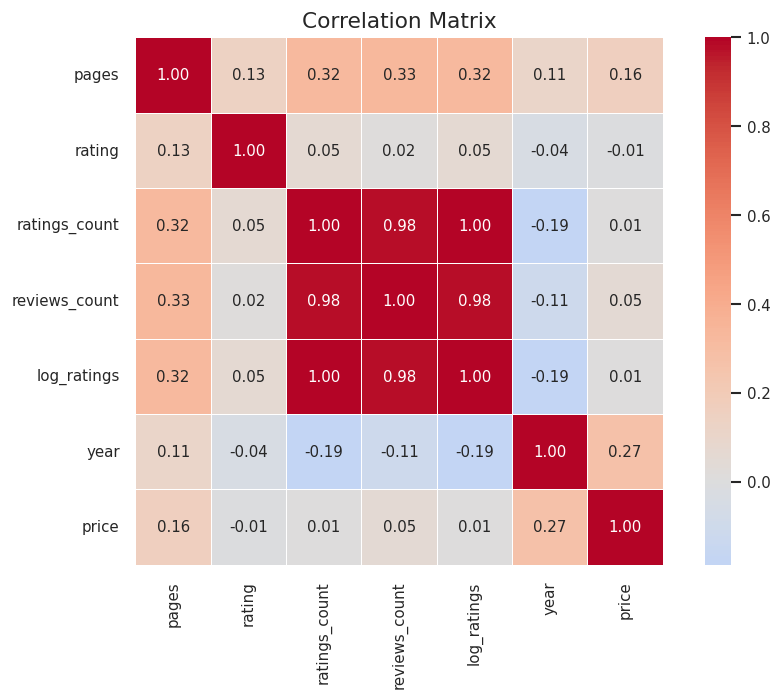

In [73]:
num_cols = ['pages','rating','ratings_count','reviews_count','log_ratings','year','price']
corr = df[num_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, annot_kws={'size':9}, ax=ax)
ax.set_title('Correlation Matrix')
plt.tight_layout(); plt.show()

- Ratings count and reviews count exhibit an extremely strong positive correlation, indicating that books with larger readership generally generate more reader discussions and written engagement
- Page count shows a moderate positive correlation with popularity-related features
- Publication year exhibits weak negative correlation

### Popularity Metrics
- Based on the EDA, ratings_count is heavily right-skewed. To create a reliable prediction target, I have defined a categorical Popularity Metric with three tiers: Niche (Bottom 50%), Rising (50-85%), and Bestseller (Top 15%).

In [74]:
# Defining the Popularity Metric using Percentiles
df['popularity_tier'] = pd.qcut(df['ratings_count'],
                                q=[0, 0.5, 0.85, 1.0],
                                labels=['Niche', 'Rising', 'Bestseller'])

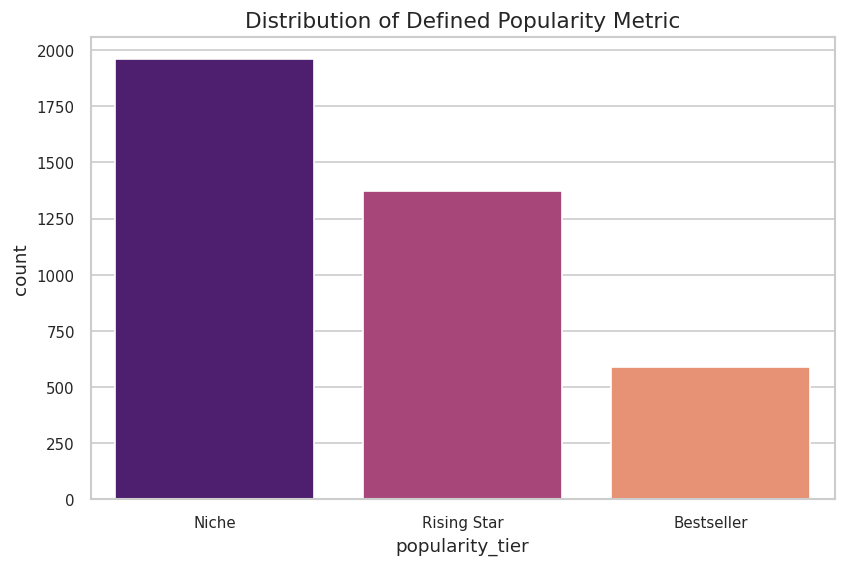

In [81]:
# plot popularity tier
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='popularity_tier',hue='popularity_tier', palette='magma')
plt.title('Distribution of Defined Popularity Metric')
plt.show()

## Final Verdict
- Here I am considering `popularity_tier` as target (derived from ratings_count)
- This turns our problem into a Classification task, which is much more stable
- Due to the extreme right-skewness , predicting raw numbers is prone to high error. So segmenting books into Niche (0-50%), Rising (50-85%), and Bestseller (85-100%)

